# Housing Price Prediction using Linear Regression

## Project Objective

The objective of this project is to build a Linear Regression model that predicts house prices based on various housing features.

This project covers:

- Data Loading
- Data Exploration
- Data Cleaning
- Exploratory Data Analysis
- Feature Encoding
- Model Training
- Model Evaluation
- Visualization

In [2]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [3]:
#load dataset
housing = pd.read_csv("Housing.csv")
housing.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## Dataset Shape

Check the number of rows and columns.

In [4]:
housing.shape

(545, 13)

## Dataset Information

Display information about the dataset including data types.

In [5]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


## Check Missing Values

Identify missing values in each column.

In [6]:
housing.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


## Statistical Summary

Generate descriptive statistics for numerical columns.

In [8]:
housing.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


## Exploratory Data Analysis

Visualize the distribution of house prices.

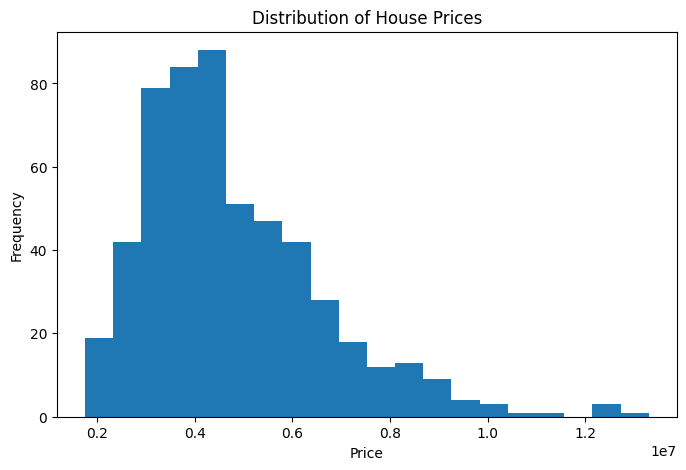

In [9]:
plt.figure(figsize=(8,5))

plt.hist(housing["price"],bins=20)

plt.xlabel("Price")

plt.ylabel("Frequency")

plt.title("Distribution of House Prices")

plt.show()

## Correlation Matrix

Check the relationship between numerical variables.

In [10]:
numeric_data = housing.select_dtypes(include=np.number)

numeric_data.corr()

,price,area,bedrooms,bathrooms,stories,parking
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.384394
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.352980
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.139270
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.177496
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.045547
parking,0.384394,0.352980,0.139270,0.177496,0.045547,1.000000


## Encode Categorical Variables

Convert categorical values into numerical values using Label Encoding.

In [11]:
encoder = LabelEncoder()

for col in housing.columns:

    if housing[col].dtype=="object":

        housing[col]=encoder.fit_transform(housing[col])

housing.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


## Feature Selection

Separate independent variables and target variable.


In [13]:
X = housing.drop("price",axis=1)

y = housing["price"]

## Split Dataset

Split the dataset into training and testing sets.

In [14]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Train Linear Regression Model

Create and train the Linear Regression model.

In [15]:
model=LinearRegression()

model.fit(X_train,y_train)

LinearRegression()

## Predict House Prices

Predict house prices using the testing dataset.

In [16]:
y_pred=model.predict(X_test)

y_pred[:10]

array([5203691.70963178, 7257004.02115475, 3062828.59668171,
       4559591.65374424, 3332932.30559782, 3563080.67918997,
       5645466.31219972, 6413979.66873635, 2755831.54819   ,
       2668938.66075228])

## Model Evaluation

Evaluate the model using Mean Absolute Error (MAE), Mean Squared Error (MSE), and R² Score.

In [17]:
mae=mean_absolute_error(y_test,y_pred)

mse=mean_squared_error(y_test,y_pred)

r2=r2_score(y_test,y_pred)

print("Mean Absolute Error:",mae)

print("Mean Squared Error:",mse)

print("R2 Score:",r2)

Mean Absolute Error: 979679.6912959901
Mean Squared Error: 1771751116594.0352
R2 Score: 0.6494754192267803


## Actual vs Predicted Prices

Compare the actual and predicted house prices using a scatter plot.

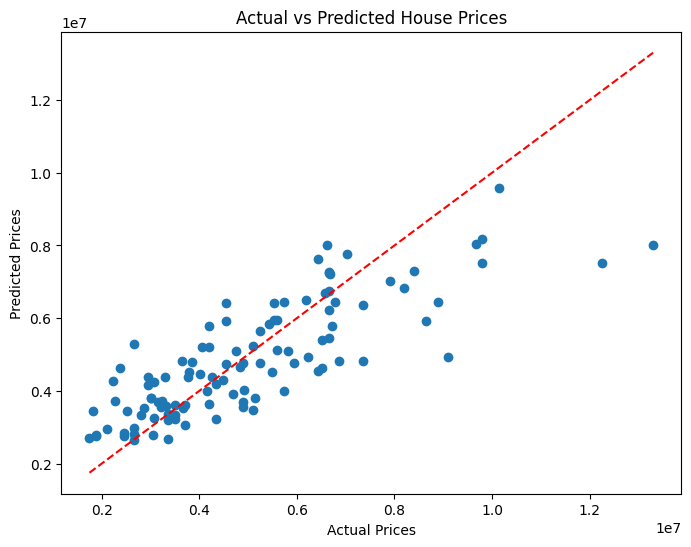

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(y_test,y_pred)

plt.xlabel("Actual Prices")

plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()],
    'r--'
)

plt.show()

# Conclusion

The Linear Regression model was successfully developed to predict house prices based on housing features.

The project included data loading, preprocessing, exploratory data analysis, feature encoding, model training, prediction, and evaluation.

The model's performance was assessed using MAE, MSE, and R² Score, providing valuable insights into predictive analytics and machine learning techniques.
